In [3]:
import pandas as pd

In [4]:
data = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\Classification\train (2).csv")

In [5]:
data.columns

Index(['id', 'perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'sourcing_channel', 'residence_area_type',
       'premium', 'renewal'],
      dtype='object')

In [6]:
data['sourcing_channel'].unique()

array(['A', 'B', 'C', 'D', 'E'], dtype=object)

In [7]:
data.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,renewal
0,66633,0.086,16805,114110,0.0,0.0,0.0,99.87,8,A,Urban,3300,1
1,62807,0.010,22638,315120,0.0,0.0,0.0,99.25,19,A,Rural,3300,1
2,30822,0.312,11685,125100,0.0,0.0,0.0,98.84,13,A,Urban,7500,1
3,101201,0.276,24829,150200,2.0,0.0,0.0,99.02,17,A,Urban,7500,1
4,63479,0.308,20445,137880,0.0,0.0,0.0,98.80,11,A,Rural,7500,1


In [8]:
data.isna().sum()

id                                     0
perc_premium_paid_by_cash_credit       0
age_in_days                            0
Income                                 0
Count_3-6_months_late                 88
Count_6-12_months_late                88
Count_more_than_12_months_late        88
application_underwriting_score      2539
no_of_premiums_paid                    0
sourcing_channel                       0
residence_area_type                    0
premium                                0
renewal                                0
dtype: int64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='application_underwriting_score', ylabel='Count'>

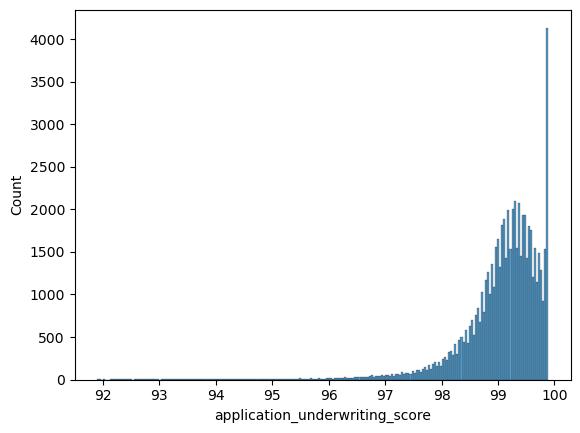

In [10]:
sns.histplot(data=data["application_underwriting_score"])

In [11]:
data.shape

(67875, 13)

In [12]:
data["Count_3-6_months_late"].value_counts()

Count_3-6_months_late
0.0     56731
1.0      7534
2.0      2128
3.0       829
4.0       323
5.0       145
6.0        59
7.0        20
8.0        12
9.0         3
12.0        1
13.0        1
10.0        1
Name: count, dtype: int64

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
si = SimpleImputer(strategy='median')

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67875 entries, 0 to 67874
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                67875 non-null  int64  
 1   perc_premium_paid_by_cash_credit  67875 non-null  float64
 2   age_in_days                       67875 non-null  int64  
 3   Income                            67875 non-null  int64  
 4   Count_3-6_months_late             67787 non-null  float64
 5   Count_6-12_months_late            67787 non-null  float64
 6   Count_more_than_12_months_late    67787 non-null  float64
 7   application_underwriting_score    65336 non-null  float64
 8   no_of_premiums_paid               67875 non-null  int64  
 9   sourcing_channel                  67875 non-null  object 
 10  residence_area_type               67875 non-null  object 
 11  premium                           67875 non-null  int64  
 12  rene

In [100]:
num_col = list(data.select_dtypes(include = "number").columns)
num_col

['id',
 'perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium',
 'renewal',
 'Total_late']

In [101]:
num_col = [
 'perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium',
 'renewal']

In [102]:
data[num_col] = si.fit_transform(data[num_col])

In [18]:
data.isna().sum().sum() == 0

np.True_

In [19]:
data

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,renewal
0,66633.0,0.086,16805.0,114110.0,0.0,0.0,0.0,99.87,8.0,A,Urban,3300.0,1.0
1,62807.0,0.010,22638.0,315120.0,0.0,0.0,0.0,99.25,19.0,A,Rural,3300.0,1.0
2,30822.0,0.312,11685.0,125100.0,0.0,0.0,0.0,98.84,13.0,A,Urban,7500.0,1.0
3,101201.0,0.276,24829.0,150200.0,2.0,0.0,0.0,99.02,17.0,A,Urban,7500.0,1.0
4,63479.0,0.308,20445.0,137880.0,0.0,0.0,0.0,98.80,11.0,A,Rural,7500.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67870,95125.0,0.000,14610.0,105110.0,0.0,0.0,0.0,99.34,9.0,A,Urban,5400.0,1.0
67871,107201.0,0.290,16795.0,30080.0,0.0,0.0,0.0,96.77,5.0,A,Urban,1200.0,1.0
67872,81642.0,0.020,11328.0,93040.0,0.0,0.0,0.0,99.66,8.0,B,Urban,11700.0,1.0
67873,113183.0,0.264,25559.0,166230.0,0.0,0.0,0.0,99.26,7.0,B,Urban,9600.0,1.0


In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
OHE = OneHotEncoder(sparse_output=False)

In [22]:
residence_area_encoded = OHE.fit_transform(data[["residence_area_type"]])

In [23]:
residence_area_encoded

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], shape=(67875, 2))

In [24]:
data[["Urban", "Rural"]] = residence_area_encoded

In [25]:
data = data.rename(columns = {"Urban":"Rural","Rural":"Urban"})

In [26]:
data

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,renewal,Rural,Urban
0,66633.0,0.086,16805.0,114110.0,0.0,0.0,0.0,99.87,8.0,A,Urban,3300.0,1.0,0.0,1.0
1,62807.0,0.010,22638.0,315120.0,0.0,0.0,0.0,99.25,19.0,A,Rural,3300.0,1.0,1.0,0.0
2,30822.0,0.312,11685.0,125100.0,0.0,0.0,0.0,98.84,13.0,A,Urban,7500.0,1.0,0.0,1.0
3,101201.0,0.276,24829.0,150200.0,2.0,0.0,0.0,99.02,17.0,A,Urban,7500.0,1.0,0.0,1.0
4,63479.0,0.308,20445.0,137880.0,0.0,0.0,0.0,98.80,11.0,A,Rural,7500.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67870,95125.0,0.000,14610.0,105110.0,0.0,0.0,0.0,99.34,9.0,A,Urban,5400.0,1.0,0.0,1.0
67871,107201.0,0.290,16795.0,30080.0,0.0,0.0,0.0,96.77,5.0,A,Urban,1200.0,1.0,0.0,1.0
67872,81642.0,0.020,11328.0,93040.0,0.0,0.0,0.0,99.66,8.0,B,Urban,11700.0,1.0,0.0,1.0
67873,113183.0,0.264,25559.0,166230.0,0.0,0.0,0.0,99.26,7.0,B,Urban,9600.0,1.0,0.0,1.0


In [27]:
from sklearn.preprocessing import TargetEncoder

In [28]:
te = TargetEncoder()

In [29]:
data["sourcing_channel_encoded"] = te.fit_transform(data[["sourcing_channel"]], data["renewal"])

In [30]:
data

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,renewal,Rural,Urban,sourcing_channel_encoded
0,66633.0,0.086,16805.0,114110.0,0.0,0.0,0.0,99.87,8.0,A,Urban,3300.0,1.0,0.0,1.0,0.944775
1,62807.0,0.010,22638.0,315120.0,0.0,0.0,0.0,99.25,19.0,A,Rural,3300.0,1.0,1.0,0.0,0.944775
2,30822.0,0.312,11685.0,125100.0,0.0,0.0,0.0,98.84,13.0,A,Urban,7500.0,1.0,0.0,1.0,0.945252
3,101201.0,0.276,24829.0,150200.0,2.0,0.0,0.0,99.02,17.0,A,Urban,7500.0,1.0,0.0,1.0,0.944775
4,63479.0,0.308,20445.0,137880.0,0.0,0.0,0.0,98.80,11.0,A,Rural,7500.0,1.0,1.0,0.0,0.944775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67870,95125.0,0.000,14610.0,105110.0,0.0,0.0,0.0,99.34,9.0,A,Urban,5400.0,1.0,0.0,1.0,0.945252
67871,107201.0,0.290,16795.0,30080.0,0.0,0.0,0.0,96.77,5.0,A,Urban,1200.0,1.0,0.0,1.0,0.944507
67872,81642.0,0.020,11328.0,93040.0,0.0,0.0,0.0,99.66,8.0,B,Urban,11700.0,1.0,0.0,1.0,0.936161
67873,113183.0,0.264,25559.0,166230.0,0.0,0.0,0.0,99.26,7.0,B,Urban,9600.0,1.0,0.0,1.0,0.935558


In [31]:
data.columns

Index(['id', 'perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'sourcing_channel', 'residence_area_type',
       'premium', 'renewal', 'Rural', 'Urban', 'sourcing_channel_encoded'],
      dtype='object')

In [32]:
data[ ['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,Rural,Urban,sourcing_channel_encoded,renewal
0,0.086,16805.0,114110.0,0.0,0.0,0.0,99.87,8.0,3300.0,0.0,1.0,0.944775,1.0
1,0.010,22638.0,315120.0,0.0,0.0,0.0,99.25,19.0,3300.0,1.0,0.0,0.944775,1.0
2,0.312,11685.0,125100.0,0.0,0.0,0.0,98.84,13.0,7500.0,0.0,1.0,0.945252,1.0
3,0.276,24829.0,150200.0,2.0,0.0,0.0,99.02,17.0,7500.0,0.0,1.0,0.944775,1.0
4,0.308,20445.0,137880.0,0.0,0.0,0.0,98.80,11.0,7500.0,1.0,0.0,0.944775,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67870,0.000,14610.0,105110.0,0.0,0.0,0.0,99.34,9.0,5400.0,0.0,1.0,0.945252,1.0
67871,0.290,16795.0,30080.0,0.0,0.0,0.0,96.77,5.0,1200.0,0.0,1.0,0.944507,1.0
67872,0.020,11328.0,93040.0,0.0,0.0,0.0,99.66,8.0,11700.0,0.0,1.0,0.936161,1.0
67873,0.264,25559.0,166230.0,0.0,0.0,0.0,99.26,7.0,9600.0,0.0,1.0,0.935558,1.0


<Axes: >

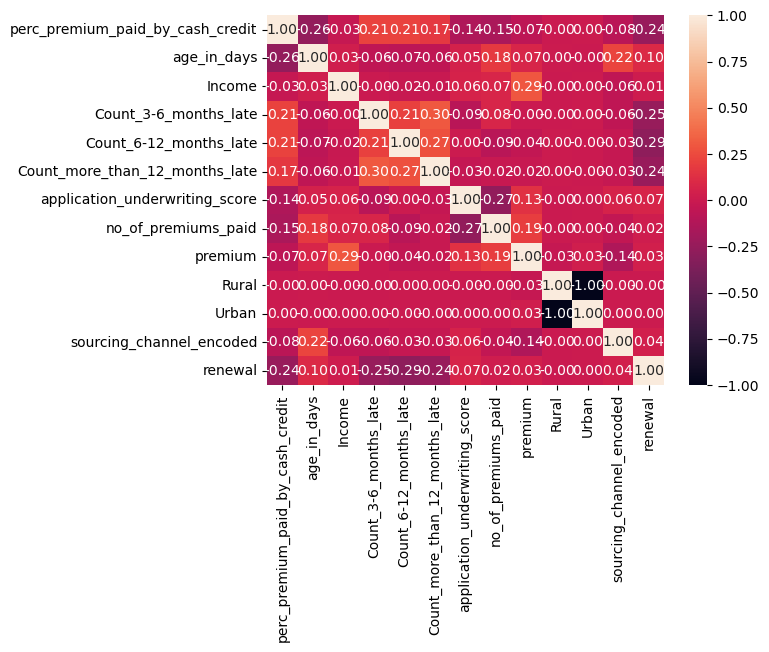

In [33]:
sns.heatmap(data[ ['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']].corr(),fmt='.2f',  annot=True)

In [34]:
data["Total_late"] =data['Count_3-6_months_late']+data['Count_6-12_months_late']+data['Count_more_than_12_months_late']

In [35]:
data["Total_late"].value_counts()

Total_late
0.0     54041
1.0      8225
2.0      2698
3.0      1247
4.0       686
5.0       414
6.0       236
7.0       147
8.0        75
9.0        44
11.0       21
10.0       16
13.0        7
12.0        6
16.0        3
14.0        3
17.0        2
15.0        2
18.0        1
19.0        1
Name: count, dtype: int64

In [36]:
data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

,perc_premium_paid_by_cash_credit,age_in_days,Income,Total_late,application_underwriting_score,no_of_premiums_paid,premium,Rural,Urban,sourcing_channel_encoded,renewal
0,0.086,16805.0,114110.0,0.0,99.87,8.0,3300.0,0.0,1.0,0.944775,1.0
1,0.010,22638.0,315120.0,0.0,99.25,19.0,3300.0,1.0,0.0,0.944775,1.0
2,0.312,11685.0,125100.0,0.0,98.84,13.0,7500.0,0.0,1.0,0.945252,1.0
3,0.276,24829.0,150200.0,2.0,99.02,17.0,7500.0,0.0,1.0,0.944775,1.0
4,0.308,20445.0,137880.0,0.0,98.80,11.0,7500.0,1.0,0.0,0.944775,1.0
...,...,...,...,...,...,...,...,...,...,...,...
67870,0.000,14610.0,105110.0,0.0,99.34,9.0,5400.0,0.0,1.0,0.945252,1.0
67871,0.290,16795.0,30080.0,0.0,96.77,5.0,1200.0,0.0,1.0,0.944507,1.0
67872,0.020,11328.0,93040.0,0.0,99.66,8.0,11700.0,0.0,1.0,0.936161,1.0
67873,0.264,25559.0,166230.0,0.0,99.26,7.0,9600.0,0.0,1.0,0.935558,1.0


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
sd = StandardScaler()

In [39]:
data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'sourcing_channel_encoded']] = sd.fit_transform(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'sourcing_channel_encoded']])

In [40]:
final_data = data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

In [41]:
## target encoding, model selection, model training, incentive ..

## Data _read
 SimpleImputer
 Total_late
 OHE
 Target_Encoding 
 StanderScaler
 train_test_split


 ## model
 Random_forest
 Xgboost

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = final_data.drop(columns="renewal")
y = final_data["renewal"]

In [44]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size= 0.2, random_state=42)

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf = RandomForestClassifier(max_depth=5)

In [47]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
from sklearn.metrics import (
confusion_matrix,
classification_report,
accuracy_score
)

In [49]:
rf_pred = rf.predict(X_test)

In [50]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.01       883
         1.0       0.94      1.00      0.97     12692

    accuracy                           0.94     13575
   macro avg       0.97      0.50      0.49     13575
weighted avg       0.94      0.94      0.90     13575



In [51]:
accuracy_score(y_test,rf_pred)

0.9351749539594844

In [52]:
rf_train_pred = rf.predict(X_train)

In [53]:
accuracy_score(y_train, rf_train_pred)

0.9384346224677717

In [54]:
from xgboost import XGBClassifier

In [55]:
XGB = XGBClassifier(max_depth =1,
                   max_leaves = 1,
                   n_estimators=50)

In [56]:
XGB.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [57]:
xgb_pred = XGB.predict(X_test)

In [58]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       883
         1.0       0.93      1.00      0.97     12692

    accuracy                           0.93     13575
   macro avg       0.47      0.50      0.48     13575
weighted avg       0.87      0.93      0.90     13575



C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [59]:
accuracy_score(xgb_pred,y_test)

0.9349539594843462

In [60]:
xgb_train_pred = XGB.predict(X_train)

In [61]:
accuracy_score(xgb_train_pred,y_train)

0.9380294659300185

In [62]:
##train accuracy > test accuracy -->overfit

In [63]:
rf.predict_proba(X_test)

array([[0.01513438, 0.98486562],
       [0.02305839, 0.97694161],
       [0.04586458, 0.95413542],
       ...,
       [0.09092034, 0.90907966],
       [0.05208848, 0.94791152],
       [0.01681713, 0.98318287]], shape=(13575, 2))

In [64]:
from sklearn.pipeline import Pipeline

In [65]:
Target_encode = Pipeline([
    ("TargetEncoder", TargetEncoder()),
    ("StandardScaler",StandardScaler())
                ])

In [66]:
from sklearn.compose import ColumnTransformer

In [67]:
num_col = list(data.select_dtypes(include = "number").columns)

In [68]:
num_col = ['perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium']

In [69]:
data_process = ColumnTransformer(
    transformers = [
        ("OHE", OneHotEncoder(sparse_output=False), ['residence_area_type']),
        ("TargetEncoder", Target_encode, ['sourcing_channel']),
        ("Standard", StandardScaler(), ['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium'])
    ]
)

In [70]:
data[num_col]

,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium
0,-0.680073,-0.393510,-0.181528,0.0,0.0,0.0,1.099812,-0.553150,-0.809401
1,-0.906889,0.724416,0.203626,0.0,0.0,0.0,0.245139,1.570067,-0.809401
2,-0.005594,-1.374786,-0.160470,0.0,0.0,0.0,-0.320048,0.411949,-0.362515
3,-0.113034,1.144333,-0.112376,2.0,0.0,0.0,-0.071917,1.184028,-0.362515
4,-0.017532,0.304116,-0.135983,0.0,0.0,0.0,-0.375188,0.025909,-0.362515
...,...,...,...,...,...,...,...,...,...
67870,-0.936733,-0.814194,-0.198773,0.0,0.0,0.0,0.369205,-0.360130,-0.585958
67871,-0.071252,-0.395426,-0.342537,0.0,0.0,0.0,-3.173552,-1.132209,-1.032844
67872,-0.877045,-1.443207,-0.221900,0.0,0.0,0.0,0.810326,-0.553150,0.084372
67873,-0.148847,1.284242,-0.081661,0.0,0.0,0.0,0.258924,-0.746169,-0.139071


In [71]:
X = data_process.fit_transform(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']], y=data["renewal"])

In [72]:
len(X[0])

10

In [73]:
renewal_pipeline = Pipeline(
    [
        ("dataprocessing", data_process),
        ("Model", RandomForestClassifier(max_depth=5))
    ]
)

In [74]:
renewal_pipeline.fit(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']], y=data["renewal"])

,steps,"[('dataprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHE', ...), ('TargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
renewal_pipeline.predict(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']])

array([1., 1., 1., ..., 1., 1., 1.], shape=(67875,))

In [103]:
import pickle

In [104]:
with open(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\Classification\renewal_pipeline.pkl", "wb") as f:
    pickle.dump(renewal_pipeline, f)

In [105]:
with open(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\Classification\Simple_Imputer.pkl", "wb") as f:
    pickle.dump(si, f)

In [81]:
#load data again
# simp

In [83]:
data = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\Classification\train (2).csv")

In [90]:
data.columns

Index(['id', 'perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'sourcing_channel', 'residence_area_type',
       'premium', 'renewal'],
      dtype='object')

In [89]:
num_cols=data.describe().columns
num_cols

Index(['id', 'perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'premium', 'renewal'],
      dtype='object')

In [87]:
cat_cols=list((set(data.columns))-(set(data.describe().columns)))
cat_cols

['sourcing_channel', 'residence_area_type']

In [92]:
data["Total_late"] =data['Count_3-6_months_late']+data['Count_6-12_months_late']+data['Count_more_than_12_months_late']

In [93]:
X = data_process.fit_transform(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']], y=data["renewal"])

In [94]:
len(X[0])

10

In [95]:
renewal_pipeline.fit(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']], y=data["renewal"])

,steps,"[('dataprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHE', ...), ('TargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
renewal_pipeline.predict(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score','no_of_premiums_paid', 'premium', 'residence_area_type','sourcing_channel']])

array([1, 1, 1, ..., 1, 1, 1], shape=(67875,))

In [98]:
X = si.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.82192228, ...,  1.08705232,
        -0.55314977, -0.80940115],
       [ 1.        ,  0.        ,  0.83637293, ...,  0.24792857,
         1.5700673 , -0.80940115],
       [ 0.        ,  1.        ,  0.83637293, ..., -0.30697584,
         0.4119489 , -0.36251452],
       ...,
       [ 0.        ,  1.        , -0.14492514, ...,  0.80283299,
        -0.55314977,  0.0843721 ],
       [ 0.        ,  1.        , -0.22335093, ...,  0.26146283,
        -0.7461695 , -0.13907121],
       [ 1.        ,  0.        , -0.29221141, ...,  1.08705232,
        -0.36013003,  0.75470204]], shape=(67875, 10))

In [99]:
num_col

['perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium']